## Installing Required Libraries
This cell installs the required libraries to ensure compatibility for recommendation models.

In [1]:
!pip uninstall -y numpy scikit-surprise
!pip install --no-cache-dir "numpy<2" "scikit-surprise==1.1.4"

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 36.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.4/154.4 kB 343.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 203.1 MB/s eta 0:00:00
  Created wheel for scikit-surprise: filename=scikit_surprise-1.1.4-cp312-cp312-linux_x86_64.whl size=2554976 sha256=ec6eedbf00bfc392514e6ca613e71e0170c510972116b748a80ac9470b62330c
  Stored in directory: /tmp/pip-ephem-wheel-cache-t3v0id_4/wheels/75/fa/bc/739bc2cb1fbaab6061854e6cfbb81a0ae52c92a502a7fa454b
Successfully built scikit-surprise
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.

## Importing Libraries
This section imports all necessary libraries for data processing, visualization, and model implementation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer

from surprise import Reader, Dataset, SVD, KNNBasic, accuracy
from surprise.model_selection import train_test_split, GridSearchCV

sns.set(style="whitegrid")

## Loading Dataset
The MovieLens dataset is loaded, including movies and ratings data used for building recommendation models.

In [3]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

movies = pd.read_csv("/content/drive/MyDrive/ml-latest-small/movies.csv")
ratings = pd.read_csv("/content/drive/MyDrive/ml-latest-small/ratings.csv")

print("Movies:", movies.shape)
print("Ratings:", ratings.shape)

Mounted at /content/drive
Movies: (9742, 3)
Ratings: (100836, 4)


In [8]:
print(ratings.head())

   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931


In [7]:
print(movies.head())



   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  


## Exploratory Data Analysis: Rating Distribution
This visualization shows how ratings are distributed across the dataset.

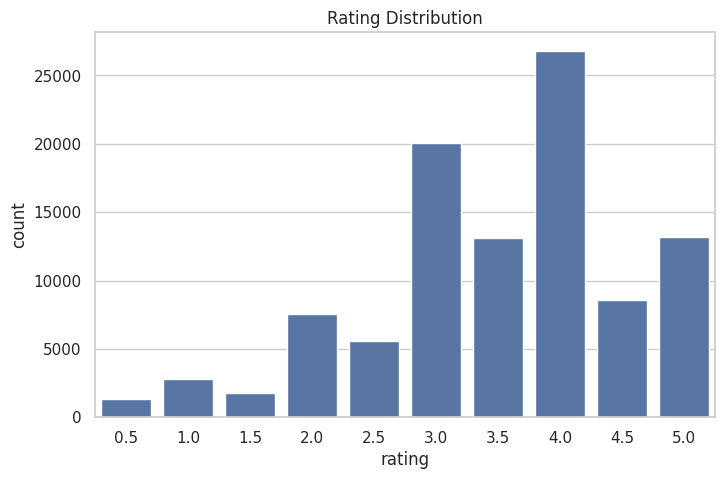

In [9]:
plt.figure(figsize=(8,5))
sns.countplot(x='rating', data=ratings)
plt.title("Rating Distribution")
plt.show()


## Exploratory Data Analysis: User Activity
This graph shows how frequently users interact with the system.

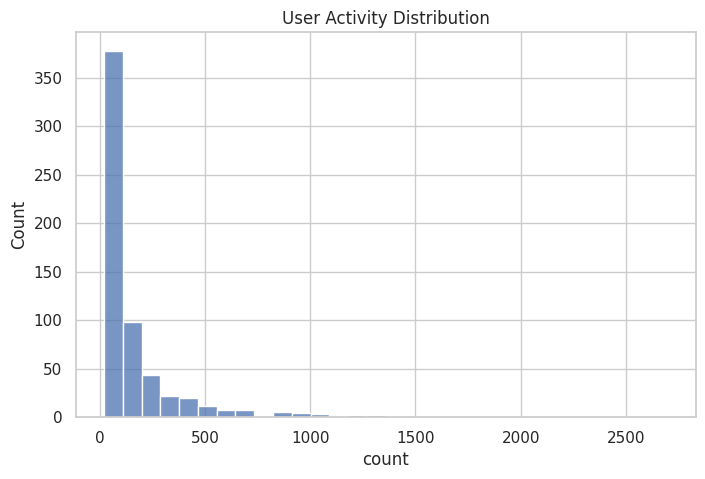

In [11]:
user_counts = ratings['userId'].value_counts()
plt.figure(figsize=(8,5))
sns.histplot(user_counts, bins=30)
plt.title("User Activity Distribution")
plt.show()

### Genre Frequency Analysis

This graph shows how movies are distributed across different genres in the dataset.
It helps to understand dataset composition and supports content-based filtering.

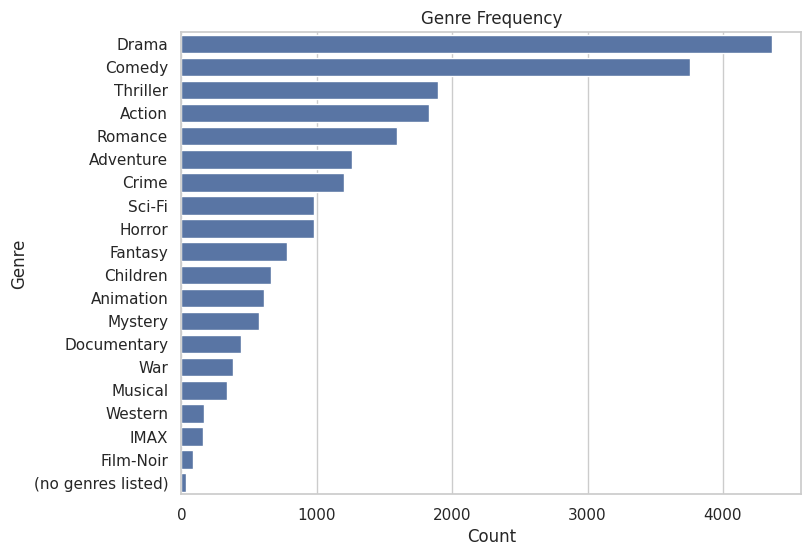

In [25]:
# Genre Frequency Analysis
genres = movies['genres'].str.split('|').explode()

plt.figure(figsize=(8,6))
sns.countplot(y=genres, order=genres.value_counts().index)
plt.title("Genre Frequency")
plt.xlabel("Count")
plt.ylabel("Genre")
plt.show()

## Data Sparsity Analysis
This section calculates sparsity to understand missing values in user-item interactions.

In [12]:
matrix = ratings.pivot_table(index='userId', columns='movieId', values='rating')
sparsity = 1 - (matrix.notna().sum().sum() / (matrix.shape[0] * matrix.shape[1]))
print("Sparsity:", round(sparsity,4))

Sparsity: 0.983


## Content-Based Filtering
This method recommends movies based on similarity of movie features using TF-IDF and cosine similarity.

In [13]:
movies['genres'] = movies['genres'].fillna('')

tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(movies['genres'])

cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)
indices = pd.Series(movies.index, index=movies['title']).drop_duplicates()

def content_recommend(title, n=5):
    idx = indices[title]
    scores = list(enumerate(cosine_sim[idx]))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)[1:n+1]
    movie_idx = [i[0] for i in scores]
    return movies['title'].iloc[movie_idx]

print(content_recommend(movies['title'].iloc[0]))


1706                                       Antz (1998)
2355                                Toy Story 2 (1999)
2809    Adventures of Rocky and Bullwinkle, The (2000)
3000                  Emperor's New Groove, The (2000)
3568                             Monsters, Inc. (2001)
Name: title, dtype: object


## Preparing Data for Collaborative Filtering
The dataset is converted into Surprise format for model training.

In [15]:
# Prepare data for collaborative filtering
reader = Reader(rating_scale=(0.5,5))
data = Dataset.load_from_df(ratings[['userId','movieId','rating']], reader)

trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

## User-Based Collaborative Filtering
This model recommends movies based on similarity between users.

In [16]:
# User-based CF
sim_user = {'name': 'cosine', 'user_based': True}
knn_user = KNNBasic(sim_options=sim_user)
knn_user.fit(trainset)

pred_user = knn_user.test(testset)
rmse_knn_user = accuracy.rmse(pred_user)
mae_knn_user = accuracy.mae(pred_user)

Computing the cosine similarity matrix...
Done computing similarity matrix.
RMSE: 0.9823
MAE:  0.7559


## Item-Based Collaborative Filtering
This model recommends movies based on similarity between items.

In [17]:
# Item-based CF
sim_item = {'name': 'cosine', 'user_based': False}
knn_item = KNNBasic(sim_options=sim_item)
knn_item.fit(trainset)

pred_item = knn_item.test(testset)
rmse_knn_item = accuracy.rmse(pred_item)
mae_knn_item = accuracy.mae(pred_item)


Computing the cosine similarity matrix...
Done computing similarity matrix.
RMSE: 0.9800
MAE:  0.7615


## Matrix Factorization using SVD
SVD is used to learn latent features and improve recommendation accuracy.

In [18]:
# SVD model
svd_model = SVD(random_state=42)
svd_model.fit(trainset)

predictions_svd = svd_model.test(testset)
rmse_svd = accuracy.rmse(predictions_svd)
mae_svd = accuracy.mae(predictions_svd)


RMSE: 0.8807
MAE:  0.6766


## SVD error distribution
The SVD error distribution illustrates the absolute difference between predicted and actual ratings. Most errors are concentrated near lower values, indicating that the model predictions are generally accurate. This confirms the effectiveness of SVD in minimizing prediction error

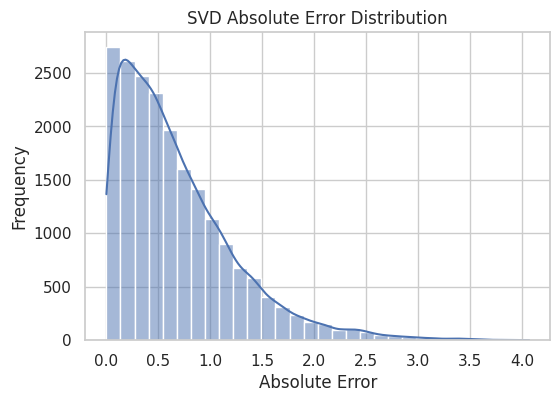

In [26]:
# SVD Error Distribution
errors_svd = [abs(pred.est - pred.r_ui) for pred in predictions_svd]

plt.figure(figsize=(6,4))
sns.histplot(errors_svd, bins=30, kde=True)
plt.title("SVD Absolute Error Distribution")
plt.xlabel("Absolute Error")
plt.ylabel("Frequency")
plt.show()

##latent factor distribution

The latent factor distribution represents the learned hidden features from the SVD model. These factors capture underlying user preferences and movie characteristics. The distribution demonstrates how the model encodes complex relationships in a lower-dimensional space

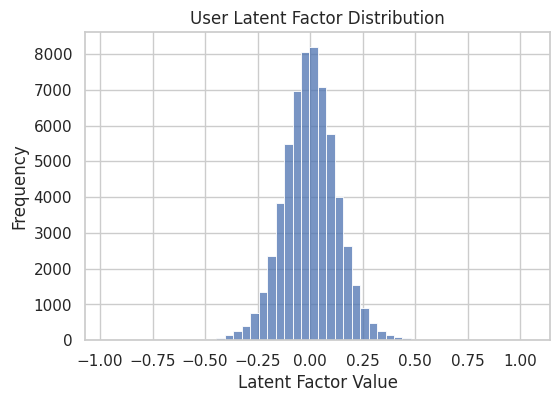

In [27]:
# Latent Factor Distribution
plt.figure(figsize=(6,4))
sns.histplot(svd_model.pu.flatten(), bins=50)
plt.title("User Latent Factor Distribution")
plt.xlabel("Latent Factor Value")
plt.ylabel("Frequency")
plt.show()

## Hyperparameter Tuning
GridSearchCV is used to optimize SVD parameters for improved performance.

In [19]:
# Hyperparameter tuning
param_grid = {
    "n_factors": [50, 100],
    "n_epochs": [20, 30],
    "lr_all": [0.002, 0.005],
    "reg_all": [0.02, 0.1]
}

gs = GridSearchCV(SVD, param_grid, measures=["rmse"], cv=3)
gs.fit(data)

best_params = gs.best_params["rmse"]
print("Best Params:", best_params)

Best Params: {'n_factors': 100, 'n_epochs': 30, 'lr_all': 0.005, 'reg_all': 0.1}


## Tuned SVD Model
The optimized SVD model is trained using the best parameters.

In [20]:
# Tuned SVD
svd_best = SVD(**best_params, random_state=42)
svd_best.fit(trainset)

pred_best = svd_best.test(testset)
rmse_tuned_svd = accuracy.rmse(pred_best)
mae_tuned_svd = accuracy.mae(pred_best)

RMSE: 0.8718
MAE:  0.6700


## Evaluation using Precision@K and Recall@K
These metrics evaluate recommendation quality based on relevance.

In [21]:
# Precision & Recall
def precision_recall_at_k(predictions, k=5, threshold=3.5):
    user_est_true = defaultdict(list)

    for uid, iid, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))

    precisions = {}
    recalls = {}

    for uid, user_ratings in user_est_true.items():
        user_ratings.sort(key=lambda x: x[0], reverse=True)
        top_k = user_ratings[:k]

        n_rel = sum((true_r >= threshold) for (_, true_r) in user_ratings)
        n_rec_k = sum((est >= threshold) for (est, _) in top_k)
        n_rel_and_rec_k = sum(((true_r >= threshold) and (est >= threshold)) for (est, true_r) in top_k)

        precisions[uid] = n_rel_and_rec_k / n_rec_k if n_rec_k != 0 else 0
        recalls[uid] = n_rel_and_rec_k / n_rel if n_rel != 0 else 0

    precision = sum(precisions.values()) / len(precisions)
    recall = sum(recalls.values()) / len(recalls)

    return precision, recall

precision, recall = precision_recall_at_k(pred_best, k=5)

print("Precision@5:", round(precision,4))
print("Recall@5:", round(recall,4))

Precision@5: 0.7538
Recall@5: 0.3844


## Model Comparison
This section compares performance of all models using RMSE and MAE.

In [22]:
# Model comparison
results = pd.DataFrame({
    "Model": ["User CF","Item CF","SVD","Tuned SVD"],
    "RMSE": [rmse_knn_user, rmse_knn_item, rmse_svd, rmse_tuned_svd],
    "MAE": [mae_knn_user, mae_knn_item, mae_svd, mae_tuned_svd]
})

print(results)

       Model      RMSE       MAE
0    User CF  0.982256  0.755897
1    Item CF  0.979957  0.761470
2        SVD  0.880746  0.676573
3  Tuned SVD  0.871757  0.669961


## Model Comparison
This section compares performance of all models using RMSE and MAE.

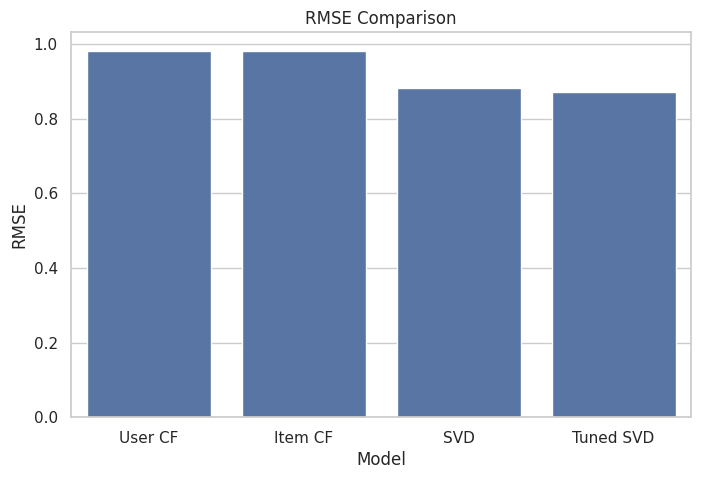

In [23]:
# Plot results
plt.figure(figsize=(8,5))
sns.barplot(x="Model", y="RMSE", data=results)
plt.title("RMSE Comparison")
plt.show()

## Final Recommendation System
This function generates personalized movie recommendations for users.

In [24]:
# Recommendation function
def recommend(user_id, n=5):
    movie_ids = ratings['movieId'].unique()
    preds = [svd_best.predict(user_id, iid) for iid in movie_ids]
    preds.sort(key=lambda x: x.est, reverse=True)
    top = preds[:n]

    return [(movies[movies['movieId']==i.iid]['title'].values[0], round(i.est,2)) for i in top]

print(recommend(ratings['userId'].iloc[0]))

[('Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1964)', 5), ('Three Billboards Outside Ebbing, Missouri (2017)', 5), ('Lawrence of Arabia (1962)', 5), ('Streetcar Named Desire, A (1951)', 5), ('Paths of Glory (1957)', 5)]
